In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from lisatools.utils.constants import YRSID_SI
from bbhx.waveformbuild import BBHWaveformFD
from antenna_pattern_utils import *

No CuPy


In [ ]:
DAY_SI = 24*3600
Tobs = YRSID_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1] # have to do this as freq[0] = 0 causes issues with the waveform generator

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))
m1 = 1e5
m2 = 2e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 0.0
inc = 2*np.pi/3  #2*np.pi/3.
lam = 0
beta= 0
psi = 3*np.pi/8
t_c = Tobs - 5*DAY_SI # chose to have the merger at 5 days before the end of the observation time

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, modes=modes, 
                            direct=True)[0]

wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)


Frequency index where waveform starts = 2469


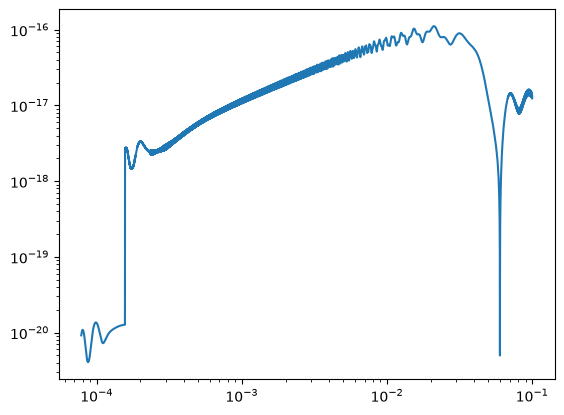

In [145]:
wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, 
                            modes=modes, 
                            direct=False,
                            length=1024,
                            squeeze=True,
                            compress=False,
                            )

print(f'Frequency index where waveform starts = {wave_freq_domain[1][0]}')
plt.loglog(freq[wave_freq_domain[1][0]:], np.abs(wave_freq_domain[0][0][0]))

In [159]:
200000/(60*60*24)

2.314814814814815

In [156]:
wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, 
                            modes=modes, 
                            direct=False,   # If direct = True, the waveform is generated directly in the frequency domain. If direct = False, the waveform is generated by interpolating <length> number of frequencies
                            length=1024,    # Default value = 1024 for speed
                            squeeze=True,   # Idk what this does
                            compress=True,  # If direct = False, it is true by default, but I am keeping it here for clarity
                            fill=True,      # Default is False. If true, the combine argument can be used
                            combine=True    # Combines all waveforms into an overlapping waveform. Usually, for one waveform, the shape is [1,3,<length of frequncies>], but if combine is True, the shape is [3,<length of frequencies>]
                            )
wave_freq_domain 

array([[ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         3.16776591e-18-1.28145237e-17j,  4.25943421e-18-1.24944433e-17j,
         5.31951079e-18-1.20815492e-17j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
        -5.62151995e-19-6.61760746e-18j,  9.71993010e-21-6.64156778e-18j,
         5.81542604e-19-6.61619975e-18j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
        -4.32867073e-18+2.68415139e-18j, -4.54379745e-18+2.30151527e-18j,
        -4.72518255e-18+1.90176935e-18j]], shape=(3, 3155815))

In [143]:
wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, 
                            modes=modes, 
                            direct=True,
                            #length=1024,
                            squeeze=True,
                            compress=False,
                            )

wave_freq_domain 

array([[[ 0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
         -1.68224200e-19+1.49995630e-19j,
         -1.80512839e-19+1.34953827e-19j,
         -1.91460690e-19+1.18909943e-19j],
        [ 0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
         -4.30315126e-21+4.33280683e-21j,
         -4.66019538e-21+3.94619946e-21j,
         -4.98262541e-21+3.53028902e-21j],
        [ 0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
          4.61488874e-18-8.51907383e-18j,
          5.33122182e-18-8.09008649e-18j,
          6.00795821e-18-7.60101783e-18j],
        [ 0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j,
          0.00000000e+00+0.00000000e+00j, ...,
         -1.09792328e-19-4.60895004e-19j,
         -6.97019520e-20-4.68633204e-19j,
         -2

In [77]:
wave_gen.amp_phase_gen.modes

[(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]

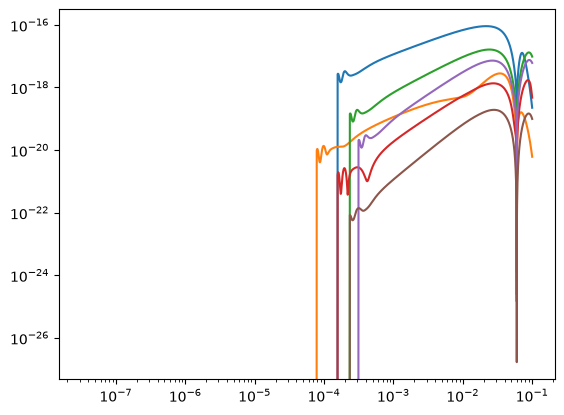

In [80]:
for i, mode in enumerate(wave_gen.amp_phase_gen.modes):
    plt.loglog(freq, np.abs(wave_freq_domain[0][i]))


In [46]:
wave_freq_domain[0][0][0]

array([-2.74832516e-21-8.74878508e-21j, -2.92427390e-21-8.75200122e-21j,
       -3.15832828e-21-8.73033915e-21j, ...,
        3.16776591e-18-1.28145237e-17j,  4.25943421e-18-1.24944433e-17j,
        5.31951079e-18-1.20815492e-17j], shape=(3153346,))

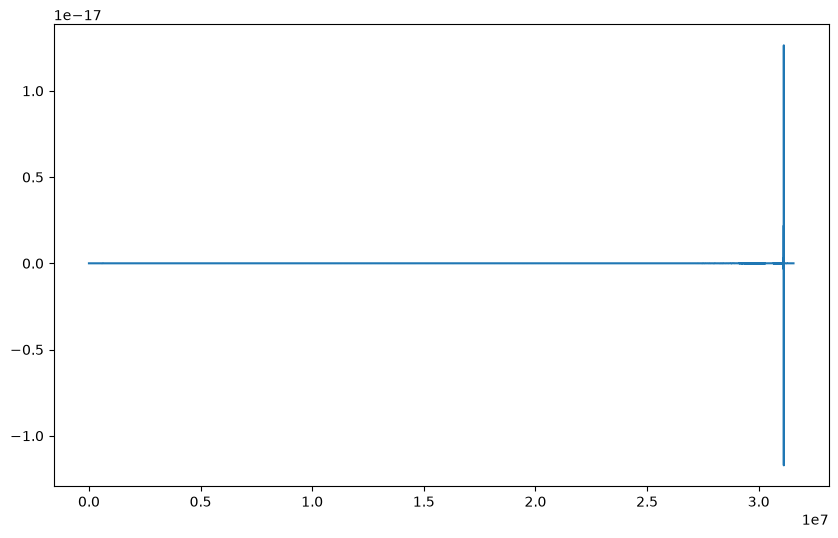

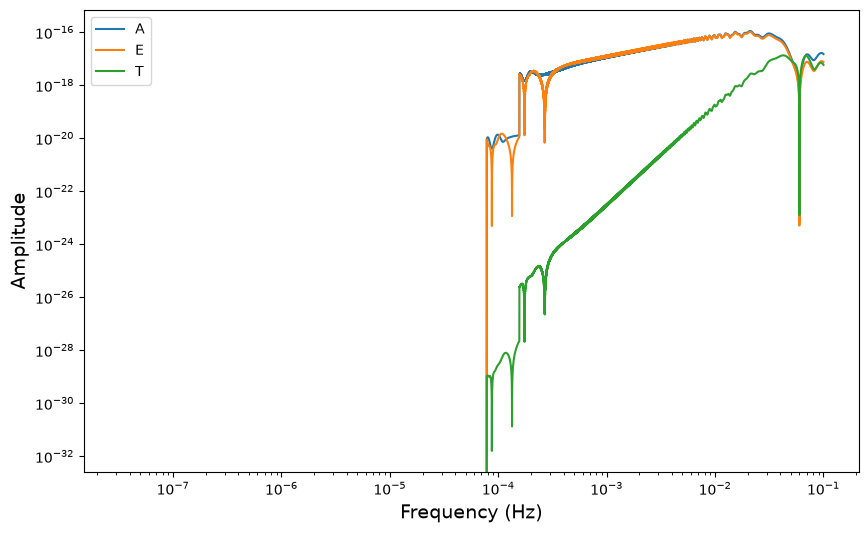

In [9]:
# plot time domain waveform
plt.figure(figsize=(10, 6))
plt.plot((np.arange(N)*dt)[0:-1], wave_time_domain[1])


# plot all frequency domain waveforms
plt.figure(figsize=(10, 6))
for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq, np.abs(wave_freq_domain[i]), label=let)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend()
plt.show()
